У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [11]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from pathlib import Path
from mlpeople.io.google_drive import download_file_iss
from mlpeople.io import save_df_zip_csv

raw_train_file_path = Path("./downloads/store_item_train.csv")
zip_train_file_path = Path("./data/train.csv.zip")

# download only if files does NOT exist
if not raw_train_file_path.exists():
    print("Downloading train file...")
    download_file_iss(
        '1AynEN7-ssczCsgnM8bjxRd_LJ5J8olln',
        output_path=str(raw_train_file_path)
    )
else:
    print("Train file already exists. Skipping download.")

raw_df = pd.read_csv(raw_train_file_path)

# save zip to repo if not there
if not zip_train_file_path.exists():
    print("Zipping train file...")
    save_df_zip_csv(raw_df, "data/train.csv")
else:
    print("Zipped train file already exists. Skipping zip.")

# read data from zipped file
store_item_df = pd.read_csv(zip_train_file_path)

# transform date to datetime and make it index
store_item_df['date'] = pd.to_datetime(store_item_df['date'])
store_item_df.set_index('date', inplace=True)

# show first 10 rows
store_item_df.head(10)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Train file already exists. Skipping download.
Zipped train file already exists. Skipping zip.


,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
2013-01-06,1,1,12
2013-01-07,1,1,10
2013-01-08,1,1,9
2013-01-09,1,1,12


In [12]:
store_item_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



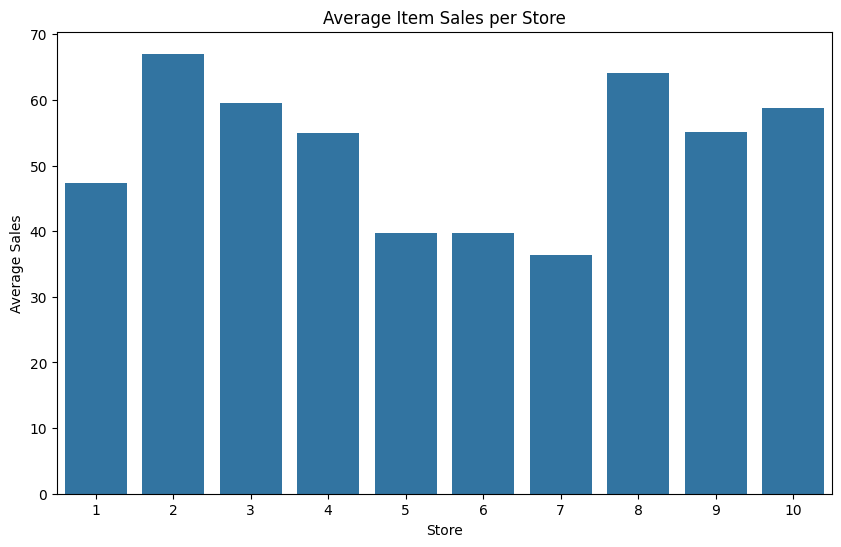

In [14]:
avg_sales_store = store_item_df.groupby('store')['sales'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=avg_sales_store, x='store', y='sales')
plt.title('Average Item Sales per Store')
plt.xlabel('Store')
plt.ylabel('Average Sales')
plt.show()

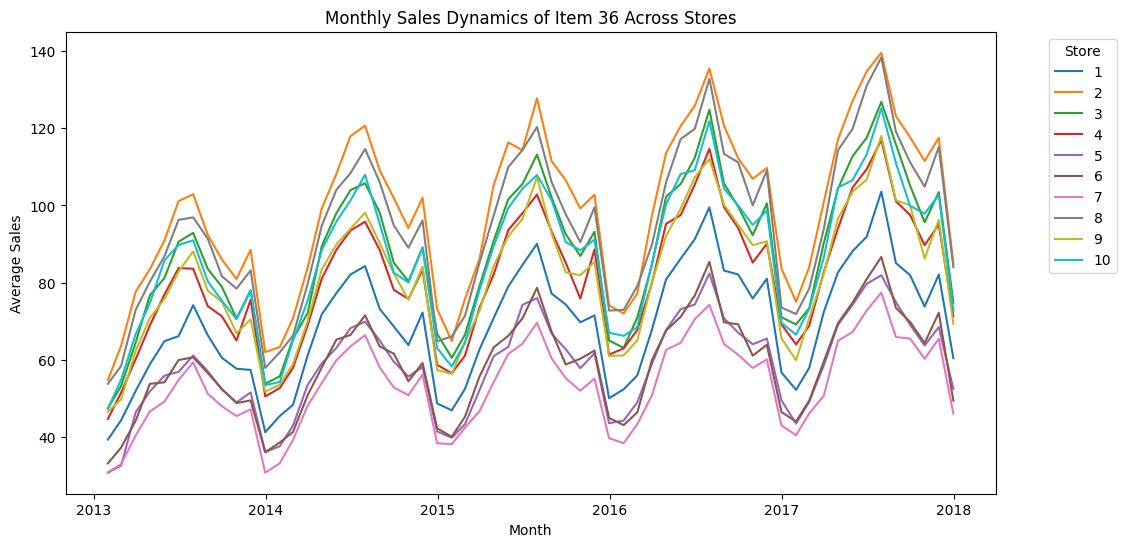

In [18]:
# Pick a random item
random_item = np.random.choice(store_item_df['item'].unique())
item_df = store_item_df[store_item_df['item'] == random_item]

# Resample per month (average sales)
item_monthly = item_df.groupby('store')['sales'].resample('ME').mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=item_monthly, x='date', y='sales', hue='store', palette='tab10')
plt.title(f'Monthly Sales Dynamics of Item {random_item} Across Stores')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.legend(title='Store', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

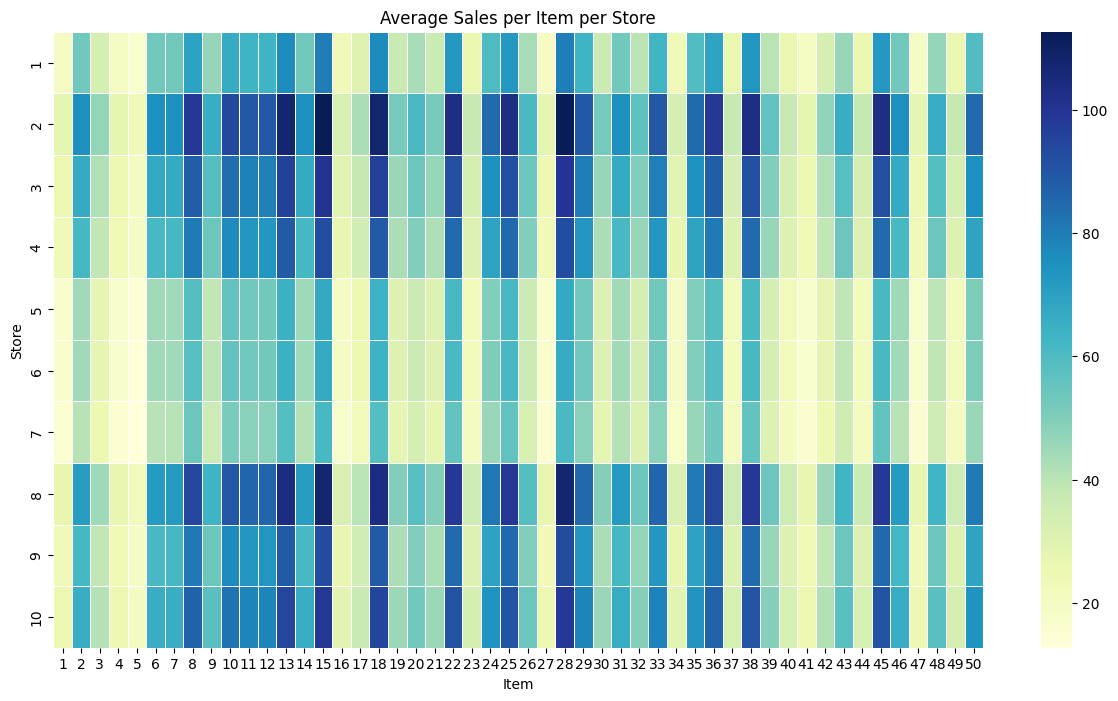

In [16]:
avg_sales_matrix = store_item_df.groupby(['store', 'item'])['sales'].mean().unstack()

plt.figure(figsize=(15,8))
sns.heatmap(avg_sales_matrix, cmap='YlGnBu', linewidths=0.5)
plt.title('Average Sales per Item per Store')
plt.xlabel('Item')
plt.ylabel('Store')
plt.show()

<span style="display: block; background-color: #f60">

 - Some stores perform better and some worse. Same for items.
 - The same items generally follow similar dynamics across all stores, but overall store performance might differ.
 - There is noticeable seasonality in sales, consistent for all stores.
 - Items that sell rarely do so in all stores, and popular items are consistently popular; no item is strong in one store and weak in another.

</span>

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

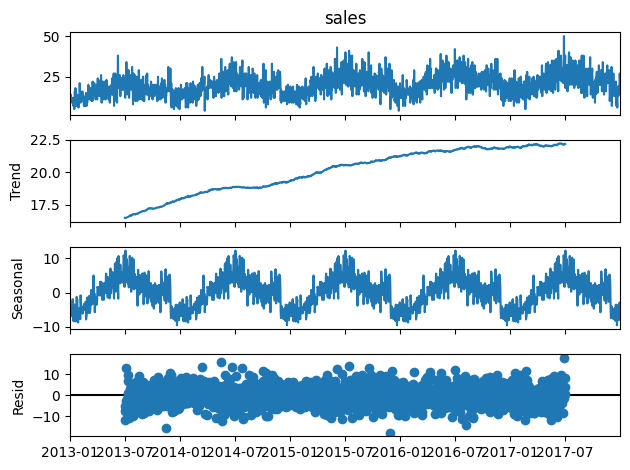

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

store_item_1_1 = store_item_df[(store_item_df["store"] == 1) & (store_item_df["item"] == 1)]

# Decompose with a yearly seasonality (period = 365 for daily data)
decomposition_plot_multi = seasonal_decompose(store_item_1_1['sales'], model='additive', period=365)
decomposition_plot_multi.plot()
plt.show()

<span style="display: block; background-color: #f60">

 - There is a clear upward trend in sales over the years.
 - There is apparent annual seasonality in sales.
 - Grouping sales by month or week could help better understand patterns and reduce noise.
 - Aggregating data can make trends and seasonal effects more visible.
 - Resampling or smoothing the data helps prevent plots from being overfilled or hard to read.

</span>

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [ ]:
# !pip install darts

In [24]:
from darts import TimeSeries

si_11_series = TimeSeries.from_dataframe(store_item_1_1, value_cols='sales')
si_11_series

,sales
date,
2013-01-01,13.0
2013-01-02,11.0
2013-01-03,14.0
2013-01-04,13.0
2013-01-05,10.0
...,...
2017-12-27,14.0
2017-12-28,19.0
2017-12-29,15.0


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

<Axes: xlabel='date'>

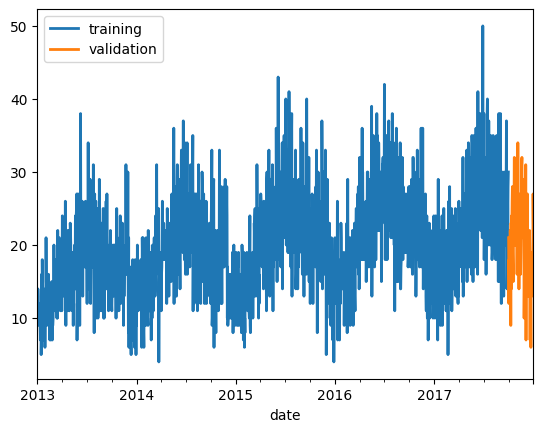

In [26]:
train_series, val_series = si_11_series.split_before(pd.Timestamp("2017-10-01"))
train_series.plot(label="training")
val_series.plot(label="validation")

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

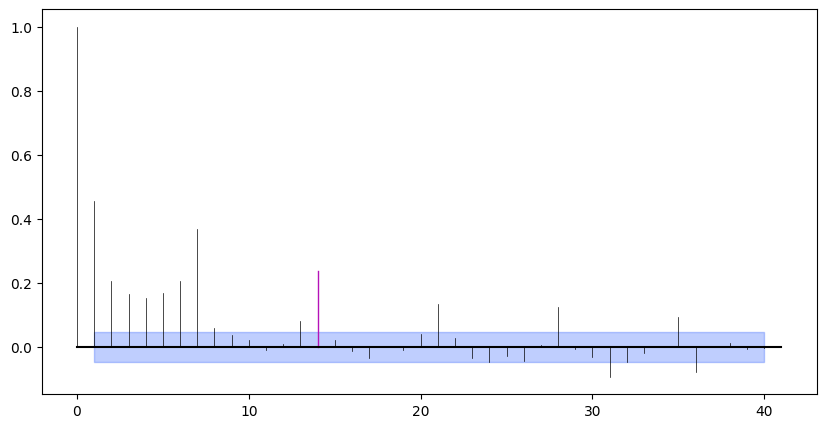

In [ ]:
from darts.utils.statistics import plot_pacf, check_seasonality

plot_pacf(train_series, m=14, alpha=0.05, max_lag=40)

<span style="display: block; background-color: #f60">

 - Lags from 1 to 7 appear to be significant and likely capture short-term temporal dependencies.
 - Weekly seasonality is evident, as lags at multiples of 7 (7×N) show strong importance.
 
 </span>

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [44]:
from darts.utils.statistics import check_seasonality

periods = []

for m in range(2, 366):
    is_seasonal, period = check_seasonality(
        train_series, m=m, alpha=0.05, max_lag=365
    )
    if is_seasonal:
        periods.append(period)

print(f"Detected seasonal periods (in days): {periods}")


Detected seasonal periods (in days): [7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 74, 77, 84, 91, 98, 105, 112, 119, 126, 133, 224, 231, 238, 245, 252, 259, 266, 273, 280, 287, 294, 301, 308, 315, 322, 329, 336, 343, 350, 357, 364]


<span style="display: block; background-color: #f60">

 - The series shows strong weekly seasonality (period = 7 days), confirmed by multiples of 7.
 - There are also signs of monthly (~30 days) and yearly (364 days) seasonal patterns.
 
</span>

8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

14. Натренуйте модель Prophet та зробіть висновок про її якість.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.